# News Classifier

## გარემოს მომზადება

თავდაპირველად დავაიმპორტე საჭირო ბიბლიოთეკები და დავაsetupე გარემო.

In [1]:
# !pip install transformers datasets evaluate accelerate

In [2]:
import kagglehub

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.nn.utils.rnn import pad_sequence

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
from sklearn.preprocessing import LabelEncoder

import re
import os
import warnings

import torch
from transformers import (
    RobertaTokenizerFast,
    RobertaForSequenceClassification,
    RobertaConfig,
    Trainer,
    TrainingArguments
)
from transformers.modeling_outputs import SequenceClassifierOutput
from transformers.models.roberta.modeling_roberta import RobertaForSequenceClassification
from datasets import load_dataset, Dataset

warnings.filterwarnings("ignore")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

kagglehub.login()

Kaggle credentials set.
Kaggle credentials successfully validated.


## მონაცემების წაკითხვა

ორ დატასეტს გავაერთიანებ, bbc-news datasetსა და Huffpost datasetს. ხუთ კატეგორიას განვიხილავ: ბიზნესი, გართობა, პოლიტიკა, სპორტი, ტექნოლოგია.

### BBC newsის წაკითხვა

In [3]:
bbc_news_path = kagglehub.competition_download("learn-ai-bbc")

bbc_train_data_path = f"{bbc_news_path}/BBC News Train.csv"
bbc_test_data_path = f"{bbc_news_path}/BBC News Test.csv"

bbc_train_df = pd.read_csv(bbc_train_data_path, sep=',')
bbc_test_df = pd.read_csv(bbc_test_data_path, sep=',')

bbc_train_df.head()

,ArticleId,Text,Category
0,1833,worldcom ex-boss launches defence lawyers defe...,business
1,154,german business confidence slides german busin...,business
2,1101,bbc poll indicates economic gloom citizens in ...,business
3,1976,lifestyle governs mobile choice faster bett...,tech
4,917,enron bosses in $168m payout eighteen former e...,business


### Huffpostის წაკითხვა

In [4]:
news_category_dataset_path = kagglehub.dataset_download("rmisra/news-category-dataset")

json_path = os.path.join(news_category_dataset_path, 'News_Category_Dataset_v3.json')

huffpost_df = pd.read_json(json_path, lines=True)

huffpost_df.head()

,link,headline,category,short_description,authors,date
0,https://www.huffpost.com/entry/covid-boosters-...,Over 4 Million Americans Roll Up Sleeves For O...,U.S. NEWS,Health experts said it is too early to predict...,"Carla K. Johnson, AP",2022-09-23
1,https://www.huffpost.com/entry/american-airlin...,"American Airlines Flyer Charged, Banned For Li...",U.S. NEWS,He was subdued by passengers and crew when he ...,Mary Papenfuss,2022-09-23
2,https://www.huffpost.com/entry/funniest-tweets...,23 Of The Funniest Tweets About Cats And Dogs ...,COMEDY,"""Until you have a dog you don't understand wha...",Elyse Wanshel,2022-09-23
3,https://www.huffpost.com/entry/funniest-parent...,The Funniest Tweets From Parents This Week (Se...,PARENTING,"""Accidentally put grown-up toothpaste on my to...",Caroline Bologna,2022-09-23
4,https://www.huffpost.com/entry/amy-cooper-lose...,Woman Who Called Cops On Black Bird-Watcher Lo...,U.S. NEWS,Amy Cooper accused investment firm Franklin Te...,Nina Golgowski,2022-09-22


### გაერთიანება

In [5]:
target_categories = ['POLITICS', 'TECH', 'SPORTS', 'ENTERTAINMENT', 'BUSINESS']
filtered_huffpost_df = huffpost_df[huffpost_df['category'].isin(target_categories)].copy()

filtered_huffpost_df.rename(columns={'short_description': 'Text', 'category': 'Category'}, inplace=True)
filtered_huffpost_df = filtered_huffpost_df[['Text', 'Category']]

category_map = {
    'POLITICS': 'politics',
    'TECH': 'tech',
    'SPORTS': 'sport',
    'ENTERTAINMENT': 'entertainment',
    'BUSINESS': 'business'
}
filtered_huffpost_df['Category'] = filtered_huffpost_df['Category'].map(category_map)

start_id = bbc_train_df['ArticleId'].max() + 1
filtered_huffpost_df['ArticleId'] = range(start_id, start_id + len(filtered_huffpost_df))

train_df = pd.concat([bbc_train_df, filtered_huffpost_df], ignore_index=True)

print(train_df['Category'].value_counts())
print(train_df.head())

Category
politics         35876
entertainment    17635
business          6328
sport             5423
tech              2365
Name: count, dtype: int64
   ArticleId                                               Text  Category
0       1833  worldcom ex-boss launches defence lawyers defe...  business
1        154  german business confidence slides german busin...  business
2       1101  bbc poll indicates economic gloom citizens in ...  business
3       1976  lifestyle  governs mobile choice  faster  bett...      tech
4        917  enron bosses in $168m payout eighteen former e...  business


## მონაცემების ანალიზი და დამუშავება

თავდაპირველად, ტექსტში ყველა ასოს პატარა ასოებით დავწერ, რადგან განსხვავებულ სიტყვებად არ შეხედოს ტექსტის კითხვის დროს. ასევე, პუნქტუაციას და სიმბობლოებს დიდი ალბათობით არ ექნება გავლენა ტექსტის შინაარსზე, აქედან გამომდინარე მაგათაც გადავაგდებ და ზედმეტედ spaceებსაც.

In [6]:
train_df['Text'] = train_df['Text'].str.lower()
train_df['Text'] = train_df['Text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
train_df['Text'] = train_df['Text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

თავდაპირველად, გადავაგდებ articleIDს, რადგან ის ინფორმაციას არ გვაძლევს სტატიის შიგთავსის შესახებ. ასევე, გადავაგდებ არასრულ მონაცემებს. ასევე, არ მინდა რომ ერთი და იგივე ტექსტებზე ბევჯერ დავატრენინგო და მაგეებსაც ამოვაგდებ.

In [7]:
train_df = train_df.dropna()
train_df = train_df.drop(columns=['ArticleId'])
train_df = train_df.drop_duplicates(subset='Text')

სტატიის სიგრძეებსაც დავაკვრიდების შემდეგ ჩანს, რომ სტატიების ზომების უმეტესობა საკმაოდ პატარაა და პატარა სტატია ასევე სასწავლადაც არ გამოდგება დიდად, აქედან გამომდინარე, ვაპირებ რომ სტატიების სიტყვების ქვედა ზღვარი დავუწესო. ძალიან დიდი სტატიებიც გვაქვს მართალია, მაგრამ დიდი სტატიებიდან ბევრი რაღაცის სწავლა შეუძლია და პერფორმანსშიც თუ არ იყო პრობლემა დავტოვებ მაგათ.

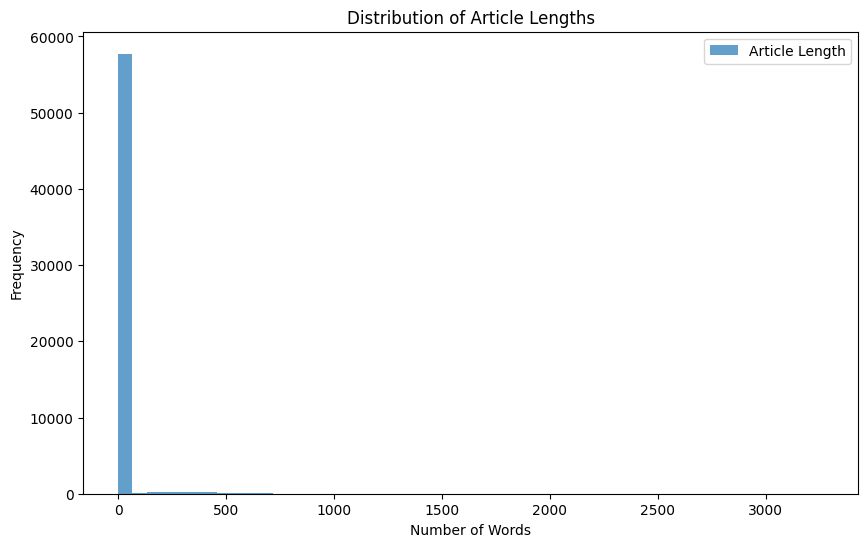

Article Lengths:
                                                Text  Article_Length
0  worldcom exboss launches defence lawyers defen...             294
1  german business confidence slides german busin...             315
2  bbc poll indicates economic gloom citizens in ...             488
3  lifestyle governs mobile choice faster better ...             623
4  enron bosses in m payout eighteen former enron...             349


In [8]:
def draw_article_lengths(df):
    df['Article_Length'] = df['Text'].apply(lambda x: len(x.split()))

    plt.figure(figsize=(10, 6))
    plt.hist(df['Article_Length'], bins=50, alpha=0.7, label='Article Length')
    plt.title('Distribution of Article Lengths')
    plt.xlabel('Number of Words')
    plt.ylabel('Frequency')
    plt.legend()
    plt.show()

    print("Article Lengths:")
    print(df[['Text', 'Article_Length']].head())

    df = df.drop(columns=['Article_Length'])

draw_article_lengths(train_df)

აქ შევეცადე ის დამესვა ზომები, რომ ტრენინგის, ტესტინგის და ვალიდაციის მონაცემებს შორის შეფარდება ყოფილიყო შესაბამისად 70%, 15% და 15%.

Filtered dataset size: 4080
Category
politics         1524
business          989
entertainment     763
sport             486
tech              318
Name: count, dtype: int64
                                                Text  Category  Article_Length
0  worldcom exboss launches defence lawyers defen...  business             294
1  german business confidence slides german busin...  business             315
2  bbc poll indicates economic gloom citizens in ...  business             488
3  lifestyle governs mobile choice faster better ...      tech             623
4  enron bosses in m payout eighteen former enron...  business             349


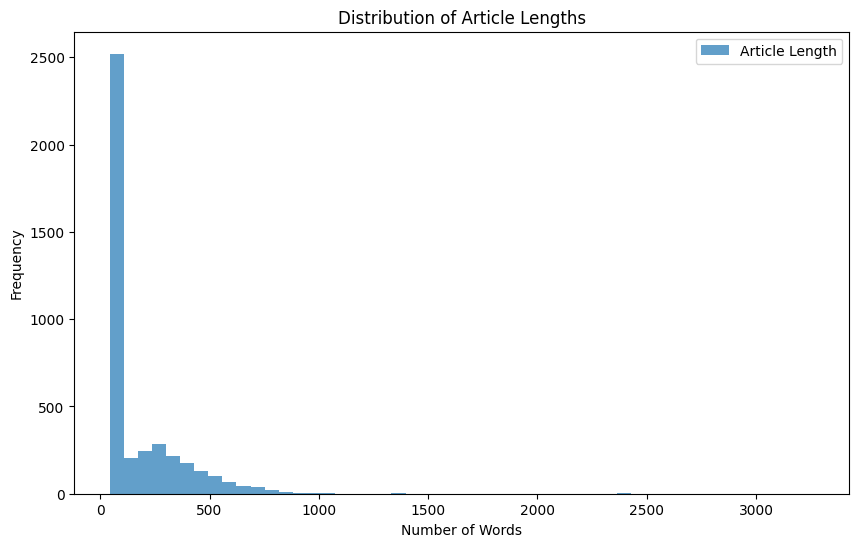

Article Lengths:
                                                Text  Article_Length
0  worldcom exboss launches defence lawyers defen...             294
1  german business confidence slides german busin...             315
2  bbc poll indicates economic gloom citizens in ...             488
3  lifestyle governs mobile choice faster better ...             623
4  enron bosses in m payout eighteen former enron...             349


In [9]:
train_df['Article_Length'] = train_df['Text'].apply(lambda x: len(x.split()))

train_df = train_df[train_df['Article_Length'] > 42].reset_index(drop=True)

print(f"Filtered dataset size: {len(train_df)}")
print(train_df['Category'].value_counts())
print(train_df.head())

train_df = train_df.drop(columns=['Article_Length'])

draw_article_lengths(train_df)

ახლა კატეგორიების განაწილებს დავაკვირდები. დიდი განსხვავება მაქვს სხვადასხვა მონაცემებს შორის, რის გამოც შეწონილად გავუშვებ სწავლებას, რომ ნაკლებად შემხვედრი კატეგორიები არ დაიჩაგრონ.

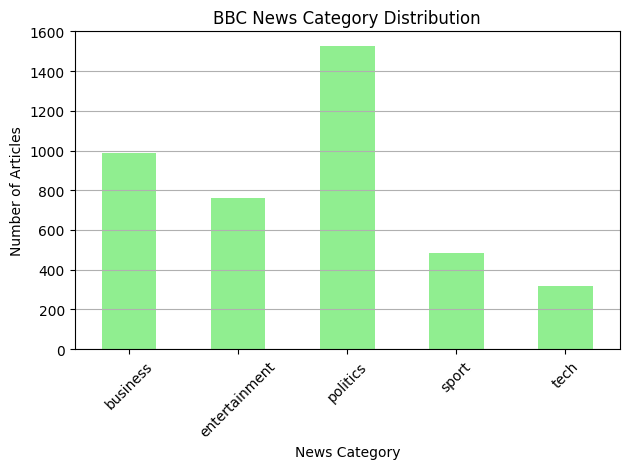

In [10]:
train_df['Category'].value_counts().sort_index().plot(kind='bar', color='lightgreen')

plt.title('BBC News Category Distribution')
plt.xlabel('News Category')
plt.ylabel('Number of Articles')
plt.xticks(rotation=45)
plt.grid(axis='y')

plt.tight_layout()
plt.show()

## მოდელი - RoBERTa

რადგან ტექსტის კლასიფიკაცია მინდა encoderის გამოყენება მჭირდება, რადგან ეგეთი ტასკებისთვის ეგ არქიტექტურა უფრო გამოსადეგია ხოლმე. აქედან გამომდინარე, bertის გამოყენება ლოგიკური იქნება, მაგრამ RoBERTa უბრალოდ უკეთესი bertია და აქედან გამომდინარე რობერტას გამოვიყენებ.

In [11]:
model = RobertaForSequenceClassification.from_pretrained('roberta-base', num_labels=5)

Some weights of RobertaForSequenceClassification were not initialized from the model checkpoint at roberta-base and are newly initialized: ['classifier.dense.bias', 'classifier.dense.weight', 'classifier.out_proj.bias', 'classifier.out_proj.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


## ტრენინგი

### ჰიპერპარამეტრები

In [12]:
OUTPUT_DIR = './results'
NUM_TRAIN_EPOCHS = 3
PER_DEVICE_TRAIN_BATCH_SIZE = 16
PER_DEVICE_EVAL_BATCH_SIZE = 64
WARMUP_STEPS = 500
WEIGHT_DECAY = 0.01
LOGGING_DIR = './logs'
LOGGING_STEPS = 10
EVAL_STRATEGY = "epoch"
SAVE_STRATEGY = "epoch"
LOAD_BEST_MODEL_AT_END = True
METRIC_FOR_BEST_MODEL = "f1"

### Datasetის მომზადება

RoBERTaმ რომ კარგად მიიღოს ჩემი არგუმენტები აქედან გამომდინარე, tokenizerს ვუკეთებ და ასევე categoryის labels სვეტში გადავწერ ინტად. ასევე როგორც მაღლა ვახსენე 3200, 700, 700ად გავსპლიტე მონაცემები, რადგან 70–15–15 შეფარდებით დამეყო ის.

In [13]:
tokenizer = RobertaTokenizerFast.from_pretrained('roberta-base')

le = LabelEncoder()
train_df['labels'] = le.fit_transform(train_df['Category'])

dataset = Dataset.from_pandas(train_df[['Text', 'labels']])

train_df, val_df = train_test_split(train_df, test_size=700, stratify=train_df['Category'], random_state=42)

train_dataset = Dataset.from_pandas(train_df[['Text', 'labels']])
val_dataset = Dataset.from_pandas(val_df[['Text', 'labels']])

def tokenize_function(examples):
    tokens = tokenizer(examples['Text'], padding='max_length', truncation=True)
    tokens['labels'] = examples['labels']
    return tokens

train_dataset = train_dataset.map(tokenize_function, batched=True)
val_dataset = val_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/3380 [00:00<?, ? examples/s]

Map:   0%|          | 0/700 [00:00<?, ? examples/s]

### შეწონვის მომზადება

როგორც მაღლა ვნახეთ, თანაბრად არ გვხვდება განსხავავებული კატეგორიები, რის გამოც სწავლების დროს წონას ვანიჭებ, რათა ყველა ტიპის კატეგორია თანაბრად კარგად ისწავლოს.

In [14]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_df['labels']),
    y=train_df['labels'],
)

class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)

### თვით ტრენინგი

trainerს რომ გამოეყენებინა class_weightები მაგის გამო wrapper კლასი მაქვს, სადაც დამატებით არგუმენტად გადავცემ class_weightებს.

In [15]:
class CustomTrainer(Trainer):
    def __init__(self, class_weights=None, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.class_weights = class_weights

    def compute_loss(self, model, inputs, return_outputs=False, **kwargs):
        labels = inputs.get("labels")

        model_inputs = {
            k: v for k, v in inputs.items()
            if k in ["input_ids", "attention_mask", "token_type_ids"]
        }

        outputs = model(**model_inputs)
        logits = outputs.logits

        loss_fct = nn.CrossEntropyLoss(weight=self.class_weights)
        loss = loss_fct(logits.view(-1, logits.shape[-1]), labels.view(-1))

        return (loss, outputs) if return_outputs else loss


def compute_metrics(eval_pred):
    logits, labels = eval_pred
    predictions = logits.argmax(axis=-1)

    return {
        "accuracy": accuracy_score(labels, predictions),
        "f1": f1_score(labels, predictions, average="weighted"),
        "precision": precision_score(labels, predictions, average="weighted"),
        "recall": recall_score(labels, predictions, average="weighted"),
    }

In [16]:
training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    num_train_epochs=NUM_TRAIN_EPOCHS,
    per_device_train_batch_size=PER_DEVICE_TRAIN_BATCH_SIZE,
    per_device_eval_batch_size=PER_DEVICE_EVAL_BATCH_SIZE,
    warmup_steps=WARMUP_STEPS,
    weight_decay=WEIGHT_DECAY,
    logging_dir=LOGGING_DIR,
    logging_steps=LOGGING_STEPS,
    eval_strategy=EVAL_STRATEGY,
    save_strategy=SAVE_STRATEGY,
    load_best_model_at_end=LOAD_BEST_MODEL_AT_END,
    metric_for_best_model=METRIC_FOR_BEST_MODEL,
)

trainer = CustomTrainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=val_dataset,
    tokenizer=tokenizer,
    compute_metrics=compute_metrics,
    class_weights=class_weights
)

In [17]:
trainer.train()

wandb: WARNING The `run_name` is currently set to the same value as `TrainingArguments.output_dir`. If this was not intended, please specify a different run name by setting the `TrainingArguments.run_name` parameter.
wandb: Currently logged in as: ikakokhutsishvili (ikakokhutsishvili-free-university-of-tbilisi-) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,0.375000,0.388857,0.887143,0.885444,0.886982,0.887143
2,0.428800,0.390120,0.892857,0.892524,0.894077,0.892857
3,0.134900,0.436955,0.892857,0.892475,0.892874,0.892857


TrainOutput(global_step=636, training_loss=0.5515468902183029, metrics={'train_runtime': 1033.2935, 'train_samples_per_second': 9.813, 'train_steps_per_second': 0.616, 'total_flos': 2668017964584960.0, 'train_loss': 0.5515468902183029, 'epoch': 3.0})

## მიღებული შედეგის გატესტვა

მეთოდი, რომელიც გვეტყვის სტატიის კატეგორიას.

In [18]:
def predict_category(text):
    inputs = tokenizer(text, padding="max_length", truncation=True, return_tensors="pt").to(device)

    with torch.no_grad():
      outputs = model(**inputs)

    predicted_class_id = torch.argmax(outputs.logits).item()
    predicted_category = le.inverse_transform([predicted_class_id])[0]

    return predicted_category

kaggleის სატესტო მონაცემებზე გატესტვა.

In [19]:
bbc_test_df['Text'] = bbc_test_df['Text'].str.lower()
bbc_test_df['Text'] = bbc_test_df['Text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
bbc_test_df['Text'] = bbc_test_df['Text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

test_dataset = Dataset.from_pandas(bbc_test_df[['Text']])
test_dataset = test_dataset.map(lambda x: tokenizer(x['Text'], padding='max_length', truncation=True), batched=True)

trainer = Trainer(model=model)
predictions = trainer.predict(test_dataset)
predicted_labels = predictions.predictions.argmax(axis=1)

bbc_test_df['Category'] = le.inverse_transform(predicted_labels)

submission = bbc_test_df[['ArticleId', 'Category']]
submission.to_csv('submission.csv', index=False)

print("submission.csv saved successfully.")

Map:   0%|          | 0/735 [00:00<?, ? examples/s]

submission.csv saved successfully.


kaggleზე submissionის ქულა **0.97414** არის.

### კატეგორიების სხვანაირად შენახვა

In [35]:
label_map = {
    'business': 0,
    'entertaiment': 1,
    'politics': 2,
    'sport': 3,
    'tech': 4
}

inverse_label_map = {v: k for k, v in label_map.items()}

trainer = Trainer(model=model)

def tester(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    df['Text'] = df['Text'].str.lower()
    df['Text'] = df['Text'].apply(lambda x: re.sub(r'[^a-z\s]', '', x))
    df['Text'] = df['Text'].apply(lambda x: re.sub(r'\s+', ' ', x).strip())

    dataset = Dataset.from_pandas(df[['Text']])
    dataset = dataset.map(lambda x: tokenizer(x['Text'], padding='max_length', truncation=True), batched=True)

    predictions = trainer.predict(dataset)
    predicted_ids = predictions.predictions.argmax(axis=1)

    predicted_categories = le.inverse_transform(predicted_ids)

    df['Category'] = predicted_categories
    df['Category'] = df['Category'].map(label_map)

    return df[['Text', 'Category']]

testerს სასურველი df გადაეცით და სწორად დააბრუნებს შემდგომში პასუხს.

In [36]:
result_df = tester(bbc_test_df)
print(result_df.head())

Map:   0%|          | 0/735 [00:00<?, ? examples/s]

                                                Text  Category
0  qpr keeper day heads for preston queens park r...       3.0
1  software watching while you work software that...       4.0
2  d arcy injury adds to ireland woe gordon d arc...       3.0
3  india s reliance family feud heats up the ongo...       0.0
4  boro suffer morrison injury blow middlesbrough...       3.0


## მოდელის შენახვა

In [20]:
trainer.save_model("my_news_classifier")
tokenizer.save_pretrained("my_news_classifier")

('my_news_classifier/tokenizer_config.json',
 'my_news_classifier/special_tokens_map.json',
 'my_news_classifier/vocab.json',
 'my_news_classifier/merges.txt',
 'my_news_classifier/added_tokens.json',
 'my_news_classifier/tokenizer.json')